In [1]:
from datetime import datetime

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
%load_ext blackcellmagic

In [3]:
intervals = (
    pd.read_csv(
        "data/rowing.csv",
        skiprows=3,
        usecols=[2, 3] + list(range(9, 16)),
        parse_dates=["Date"],
    )
    .dropna()
    .drop(columns=["Cal/hr"])  # Essentially Watt
)

intervals = intervals[intervals["Date"] != pd.to_datetime("2024-05-06")]
intervals = intervals[intervals["Date"] != pd.to_datetime("2024-08-27")]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2024-12-20"))
    | (intervals["Time of Day"] < "12:00")
]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2025-01-02"))
    | (intervals["Time of Day"] > "15:00")
]
intervals = intervals[
    (intervals["Date"] != pd.to_datetime("2025-01-05"))
    | (intervals["Time of Day"] < "15:00")
]

intervals = intervals.rename(
    columns={col: col[:-2] for col in intervals.columns if col.endswith(".1")}
)
intervals = intervals.loc[intervals["Time"].str[3:] == "00.0"]
intervals = intervals.loc[intervals["Heart Rate"] > 0]
intervals["Interval"] = (intervals["Time"].str[:2].astype(float) / 5).astype(int)
intervals["Timestamp"] = (
    intervals["Date"]
    + pd.to_timedelta(intervals["Time of Day"] + ":00")
    + pd.to_timedelta(intervals["Time"].str.replace(".0", ":00"))
)
intervals["Efficiency"] = intervals["Watt"] / (intervals["Heart Rate"] * 5)

intervals.head(10)

,Date,Time of Day,Time,Meters,SPM,Heart Rate,/500m,Watt,Interval,Timestamp,Efficiency
1,2025-05-04,10:57,05:00.0,1018.0,24.0,132.0,02:27.3,109,1,2025-05-04 15:57:00,0.165152
2,2025-05-04,10:57,10:00.0,996.0,24.0,134.0,02:30.6,102,2,2025-05-04 20:57:00,0.152239
3,2025-05-04,10:57,15:00.0,972.0,24.0,124.0,02:34.3,95,3,2025-05-05 01:57:00,0.153226
4,2025-05-04,10:57,20:00.0,973.0,24.0,132.0,02:34.1,96,4,2025-05-05 06:57:00,0.145455
5,2025-05-04,10:57,25:00.0,966.0,24.0,129.0,02:35.2,93,5,2025-05-05 11:57:00,0.144186
6,2025-05-04,10:57,30:00.0,943.0,24.0,130.0,02:39.0,87,6,2025-05-05 16:57:00,0.133846
9,2025-04-29,10:31,05:00.0,1096.0,27.0,141.0,02:16.8,137,1,2025-04-29 15:31:00,0.194326
10,2025-04-29,10:31,10:00.0,1056.0,27.0,138.0,02:22.0,122,2,2025-04-29 20:31:00,0.176812
11,2025-04-29,10:31,15:00.0,1036.0,27.0,142.0,02:24.7,115,3,2025-04-30 01:31:00,0.161972
12,2025-04-29,10:31,20:00.0,1013.0,27.0,138.0,02:28.0,108,4,2025-04-30 06:31:00,0.156522


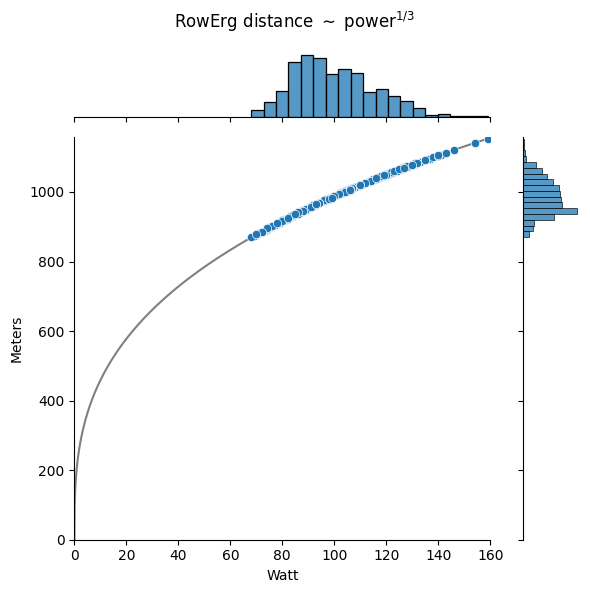

In [4]:
def distance(power, a):
    return a * power ** (1/3)


sns.jointplot(intervals, x="Watt", y="Meters", xlim=[0, 160], ylim=[0, 1159])
plt.suptitle(r"RowErg distance $\sim$ power$^{1/3}$")
popt, _ = curve_fit(distance, intervals["Watt"], intervals["Meters"])
power = np.arange(0, 170, 0.1)
plt.plot(power, distance(power, popt), color="0.5", zorder=0)
plt.tight_layout()
plt.savefig("rowing_watt-vs-meters.png")
plt.show()

In [5]:
conconi = pd.read_csv("data/rowing_conconi.csv", parse_dates=["Timestamp"])
conconi.head()

,Timestamp,Watt,Heart Rate,Machine,Step
0,2024-05-06 12:54:00,40,145,RowErg,4
1,2024-05-06 12:56:00,60,153,RowErg,4
2,2024-05-06 12:57:00,80,160,RowErg,4
3,2024-05-06 13:00:00,100,167,RowErg,4
4,2024-05-06 13:02:00,120,174,RowErg,4


In [6]:
first_timestamp = min(conconi["Timestamp"].min(), intervals["Timestamp"].min())
last_timestamp = max(conconi["Timestamp"].max(), intervals["Timestamp"].max())

compute_time = lambda timestamp: (timestamp - first_timestamp) / pd.to_timedelta("1d")
conconi["Time"] = conconi["Timestamp"].apply(compute_time)

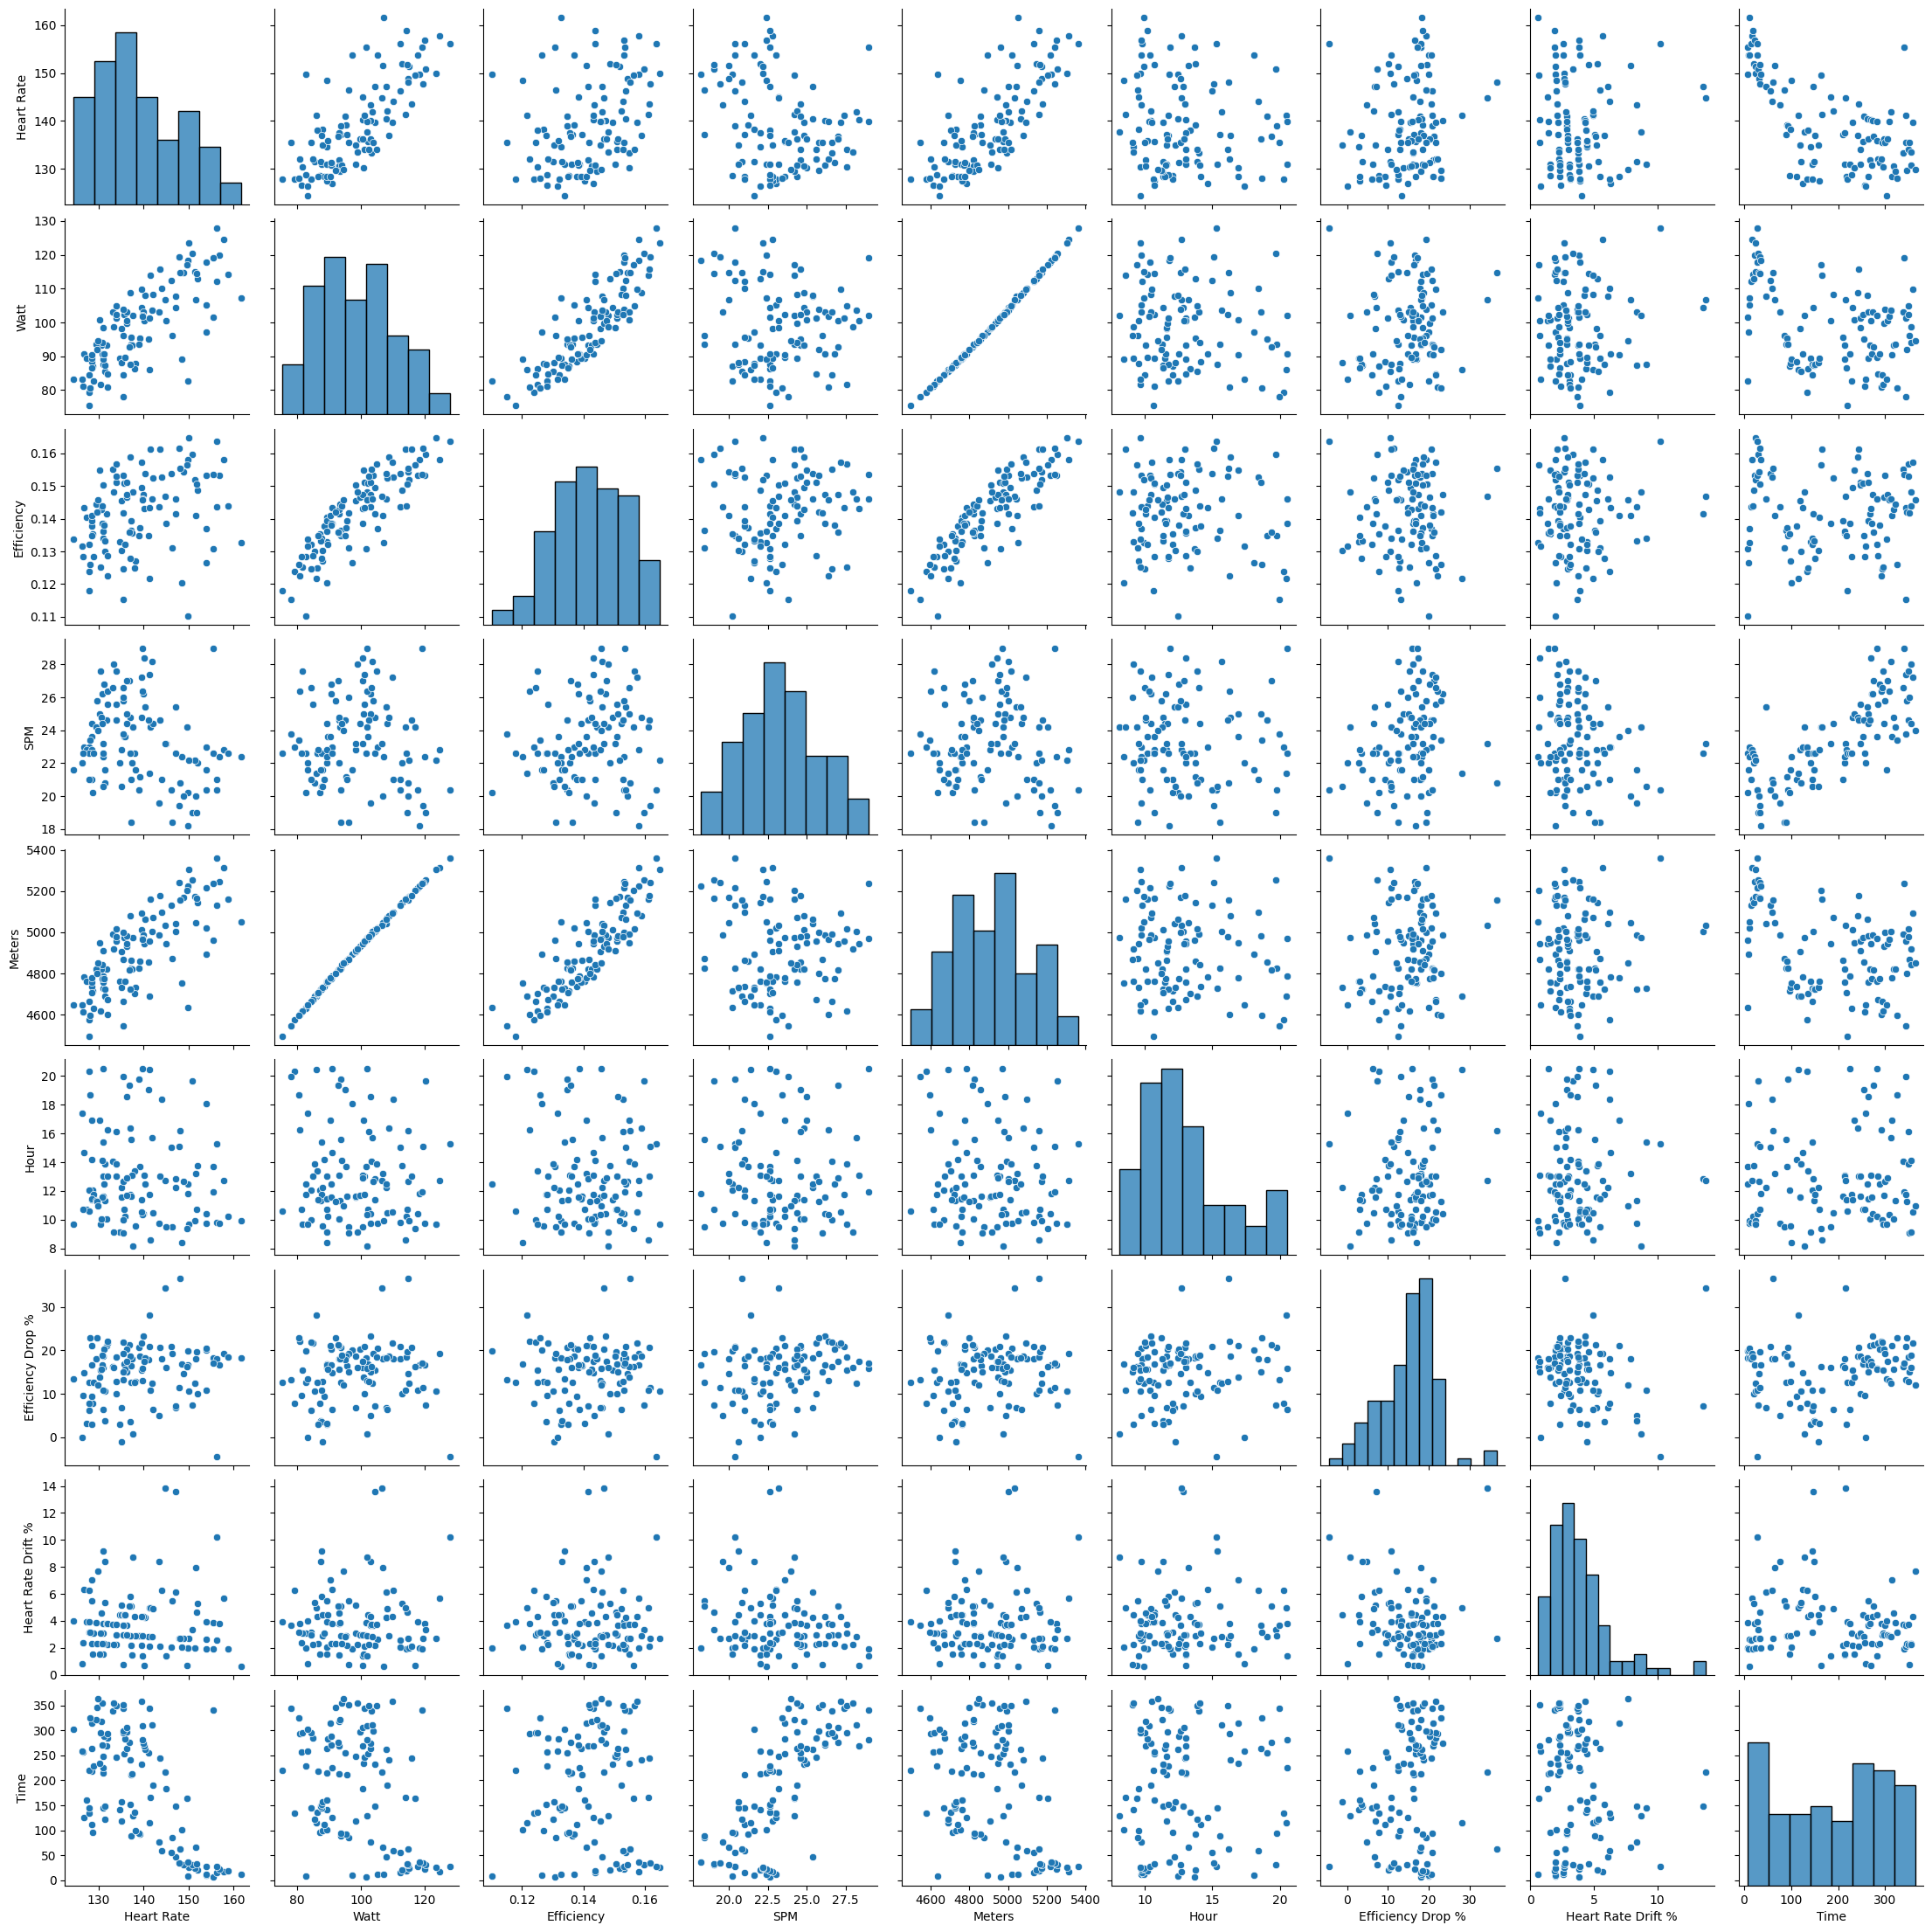

In [7]:
def analyze(session):
    """
    It usually takes me about five minutes to get into a rhythm and I usually
    row for at least half an hour. So I throw the rest away and only analyse
    the intervals two to five of each session.
    """
    if len(session) < 6:
        return

    session = session.iloc[1:6]

    result = session[["Heart Rate", "Watt", "Efficiency", "SPM"]].mean()
    result["Meters"] = session["Meters"].sum()
    result["Hour"] = pd.to_timedelta(
        session.iloc[0]["Time of Day"] + ":00"
    ) / pd.to_timedelta("1h")
    result["Efficiency Drop %"] = 100 * (
        (session["Efficiency"].iloc[0] - session["Efficiency"].iloc[-1])
        / session["Efficiency"].iloc[0]
    )
    result["Heart Rate Drift %"] = 100 * (
        (session["Heart Rate"].max() - session["Heart Rate"].min())
        / session["Heart Rate"].mean()
    )
    result["Time"] = session["Timestamp"].apply(compute_time).min()
    return result


sessions = intervals.groupby("Date").apply(analyze, include_groups=False)
sns.pairplot(sessions)
plt.savefig("rowing-data.png")
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

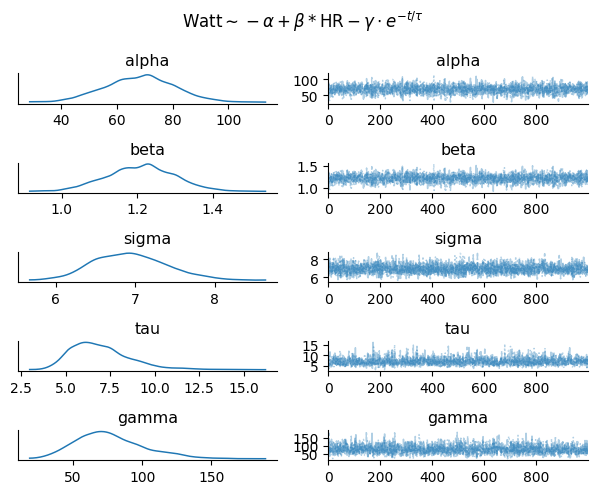

In [8]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=60)
    beta = pm.HalfNormal("beta", sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=100)
    gamma = pm.HalfNormal("gamma", sigma=60)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values
        - gamma * np.exp(-sessions["Time"].values / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal(
        "Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"].values
    )

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs)))
plt.suptitle(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-t / \tau}$"
)
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
len(sessions)

107

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

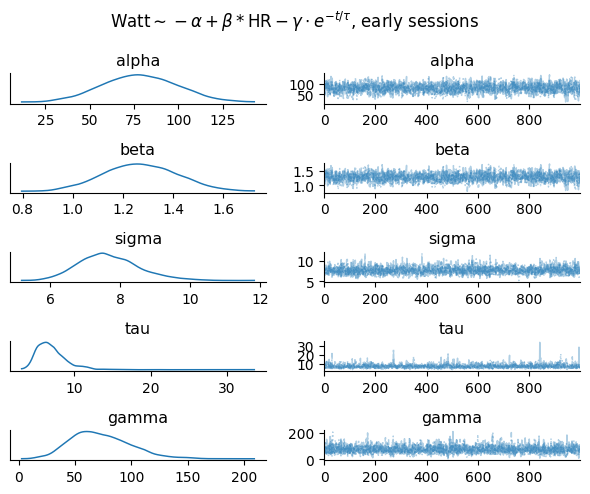

In [10]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=60)
    beta = pm.HalfNormal("beta", sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=50)
    gamma = pm.HalfNormal("gamma", sigma=60)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values[:40]
        - gamma * np.exp(-sessions["Time"].values[:40] / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal(
        "Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"].values[:40]
    )

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs)))
plt.suptitle(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-t / \tau}$, early sessions"
)
sns.despine()
plt.tight_layout()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

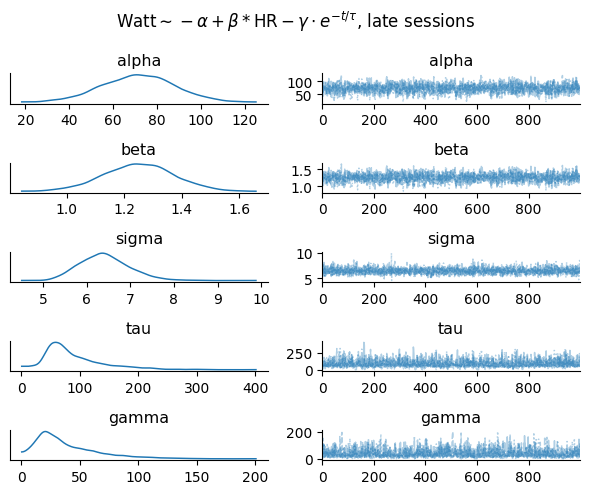

In [11]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=60)
    beta = pm.HalfNormal("beta", sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=100)
    gamma = pm.HalfNormal("gamma", sigma=60)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values[-70:]
        - gamma * np.exp(-sessions["Time"].values[-70:] / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal(
        "Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"].values[-70:]
    )

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs)))
plt.suptitle(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-t / \tau}$, late sessions"
)
sns.despine()
plt.tight_layout()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

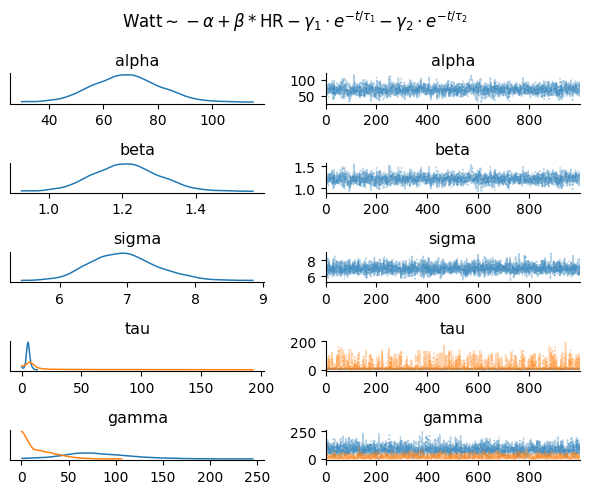

In [12]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=60)
    beta = pm.HalfNormal("beta", sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=[5, 50], shape=2)
    gamma = pm.HalfNormal("gamma", sigma=[75, 25], shape=2)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values
        - gamma[0] * np.exp(-sessions["Time"].values / tau[0])
        - gamma[1] * np.exp(-sessions["Time"].values / tau[1])
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal(
        "Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"].values
    )

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs)))
plt.suptitle(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma_1 \cdot e^{-t / \tau_1} - \gamma_2 \cdot e^{-t / \tau_2}$"
)
sns.despine()
plt.tight_layout()
plt.show()

In [13]:
conconi["Date"] = conconi["Timestamp"].dt.date
tests = conconi.pivot(columns=["Date"], index=["Watt"], values=["Heart Rate"]).iloc[:6]
tests

Heart Rate                                 
Date 2024-05-06 2024-05-09 2025-04-23 2025-05-01
Watt                                            
40        145.0      136.0        NaN        NaN
60        153.0      145.0      118.0      114.0
80        160.0      152.0      125.0      122.0
100       167.0      157.0      133.0      134.0
120       174.0      164.0      140.0      144.0
140       179.0      169.0        NaN      155.0

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

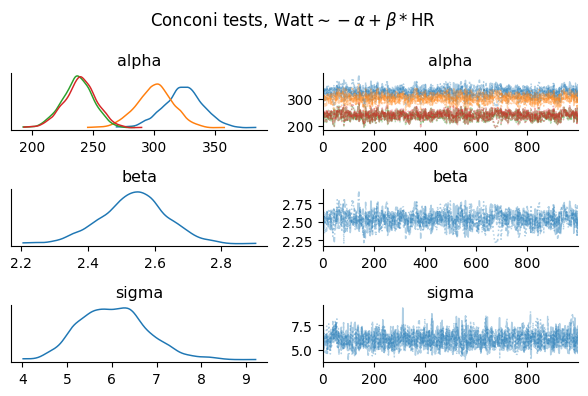

In [15]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", sigma=300, shape=len(tests.columns))
    beta = pm.Normal("beta", mu=2.5, sigma=0.2)
    sigma = pm.HalfNormal("sigma", sigma=2)

    for i, (_, test) in enumerate(tests.items()):
        test = test.dropna()

        # Expected value of outcome
        mu = -alpha[i] + beta * test.values

        # Likelihood (sampling distribution) of observations
        pm.Normal(f"Y_{i}", mu=mu, sigma=sigma, observed=test.index.values)

with model:
    conconi_trace = pm.sample(nuts_sampler="numpyro", target_accept=0.75)

az.plot_trace(conconi_trace, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
plt.suptitle(r"Conconi tests, $\text{Watt} \sim -\alpha + \beta * \text{HR}$")
plt.tight_layout()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

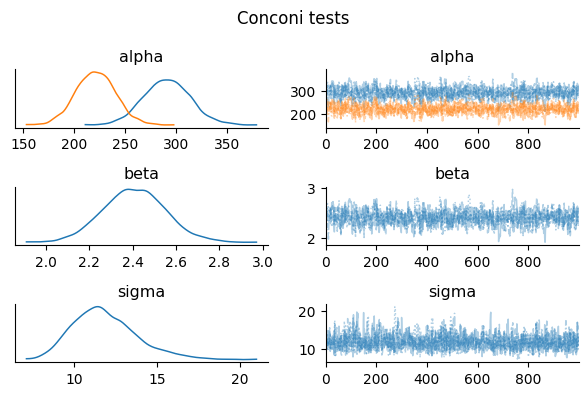

In [21]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", sigma=[275, 200], mu=50, shape=2)
    beta = pm.Normal("beta", mu=2.5, sigma=0.2)
    sigma = pm.Normal("sigma", sigma=10, mu=5)

    for i, (_, test) in enumerate(tests.items()):
        j = i // 2
        test = test.dropna()

        # Expected value of outcome
        mu = -alpha[j] + beta * test.values

        # Likelihood (sampling distribution) of observations
        pm.Normal(f"Y_{i}", mu=mu, sigma=sigma, observed=test.index.values)

with model:
    conconi_trace = pm.sample(nuts_sampler="numpyro")

az.plot_trace(conconi_trace, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
plt.suptitle("Conconi tests")
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 2 with size 2

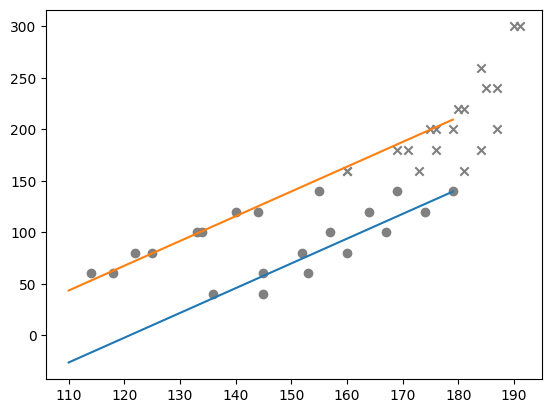

In [31]:
for query, marker in (("Watt < 150", "o"), ("Watt > 150", "x")):
    plt.scatter(
        conconi.query(query)["Heart Rate"],
        conconi.query(query)["Watt"],
        marker=marker,
        c="0.5",
    )
hr = np.arange(110, 180, 1)
for i in range(4):
    plt.plot(
        hr,
        -conconi_trace.posterior["alpha"][:, :, i].mean().values
        + conconi_trace.posterior["beta"].mean().values * hr,
    )

plt.title(r"$\text{Watt} \sim -\alpha + \beta * \text{HR}$")
plt.xlabel("Heart Rate")
plt.ylabel("Watt")

sns.despine()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

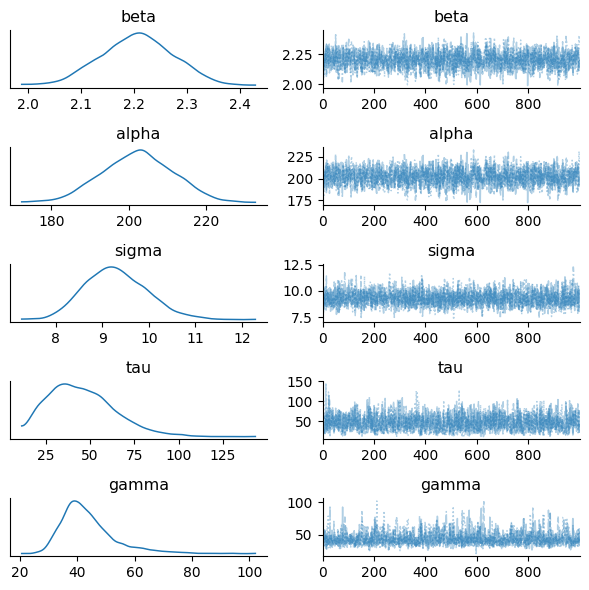

In [26]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=300)
    # beta = pm.Normal("beta", mu=2.5, sigma=0.0125)
    beta = pm.Normal(
        "beta",
        mu=conconi_trace.posterior["beta"].mean().values,
        sigma=conconi_trace.posterior["beta"].std().values / 2,
    )
    sigma = pm.HalfNormal("sigma", sigma=5)
    tau = pm.HalfNormal("tau", sigma=50)
    # delta = pm.Normal("delta", mu=0, sigma=10)
    gamma = pm.HalfNormal("gamma", sigma=60)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values
        - gamma * np.exp(-sessions["Time"].values / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
# plt.suptitle("With prior from Conconi")
plt.tight_layout()
plt.show()

In [ ]:
alpha_min = conconi_trace.posterior["alpha"].mean(("chain", "draw")).values.min()
alpha_diff = abs(
    conconi_trace.posterior["alpha"].mean(("chain", "draw")).diff("alpha_dim_0").values
)
alpha_diff_std = np.sqrt(
    (conconi_trace.posterior["alpha"].std(("chain", "draw")).values ** 2).sum()
)

alpha_min, alpha_diff, alpha_diff_std

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

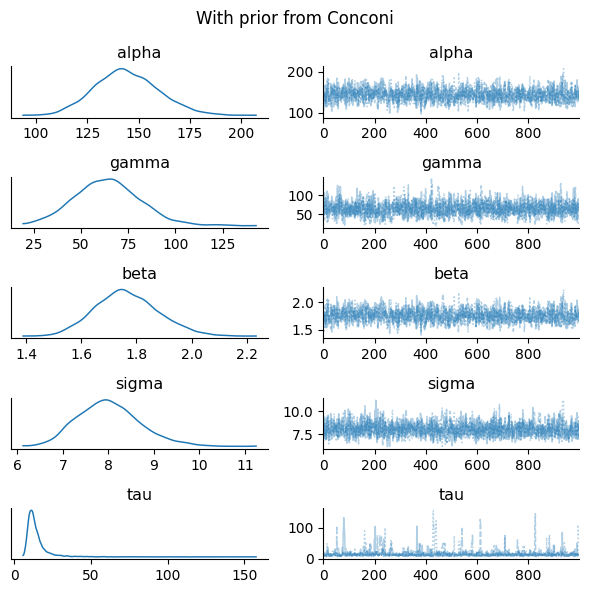

In [24]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal(
        "alpha",
        mu=alpha_min,
        sigma=conconi_trace.posterior["alpha"].std().values,
    )
    gamma = pm.Normal("gamma", mu=alpha_diff, sigma=alpha_diff_std)
    beta = pm.Normal(
        "beta",
        mu=conconi_trace.posterior["beta"].mean().values,
        sigma=conconi_trace.posterior["beta"].std().values,
    )
    sigma = pm.Normal(
        "sigma",
        mu=conconi_trace.posterior["sigma"].mean().values * 2,
        sigma=conconi_trace.posterior["sigma"].std().values * 5,
    )
    tau = pm.HalfNormal("tau", sigma=90)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values
        - gamma * np.exp(-sessions["Time"].values / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs) + 1))
sns.despine()
plt.suptitle("With prior from Conconi")
plt.tight_layout()
plt.show()

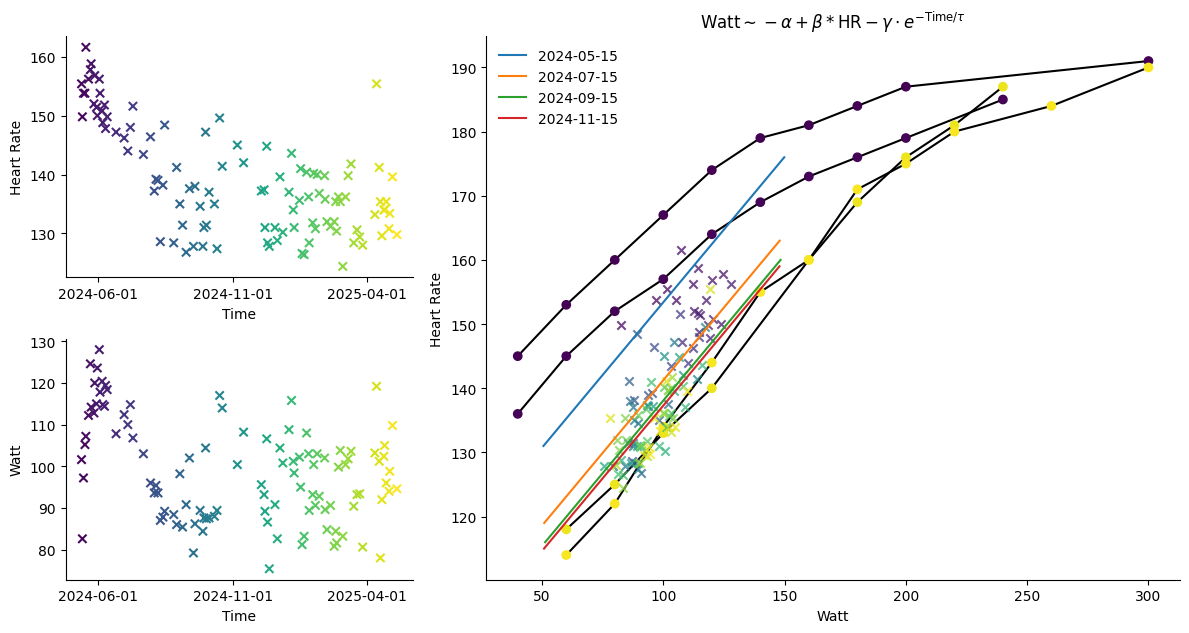

In [ ]:
fig, axd = plt.subplot_mosaic(
    [["hr", "versus"], ["watt", "versus"]],
    figsize=(12, 6.44),
    gridspec_kw={"width_ratios": [1, 2]},
)

norm = plt.Normalize(
    min(sessions["Time"].min(), conconi["Time"].min()),
    max(sessions["Time"].max(), conconi["Time"].max()),
)

axd["hr"].set_ylabel("Heart Rate")
axd["hr"].scatter(
    sessions["Time"], sessions["Heart Rate"], c=sessions["Time"], norm=norm, marker="x"
)
axd["watt"].set_ylabel("Watt")
axd["watt"].scatter(
    sessions["Time"], sessions["Watt"], c=sessions["Time"], norm=norm, marker="x"
)

dates = ["2024-06-01", "2024-11-01", "2025-04-01"]
for ax in [axd["hr"], axd["watt"]]:
    ax.set_xlabel("Time")
    ax.set_xticks([compute_time(pd.to_datetime(date)) for date in dates], dates)

axd["versus"].set_title(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-\text{Time} / \tau}$"
)
for _, data in conconi.groupby(conconi["Timestamp"].dt.date):
    axd["versus"].plot(data["Watt"], data["Heart Rate"], color="0", zorder=-1)
    axd["versus"].scatter(data["Watt"], data["Heart Rate"], c=data["Time"], norm=norm)


for _, session in sessions.iterrows():
    axd["versus"].scatter(
        session["Watt"],
        session["Heart Rate"],
        c=session["Time"],
        norm=norm,
        marker="x",
        alpha=0.75,
    )

axd["versus"].set_xlabel("Watt")
axd["versus"].set_ylabel("Heart Rate")


hr = np.arange(110, 180, 1)
for date in pd.to_datetime(["2024-05-15", "2024-07-15", "2024-09-15", "2024-11-15"]):
    time = compute_time(date)
    power = (
        -idata.posterior["alpha"].mean().values
        + idata.posterior["beta"].mean().values * hr
        - idata.posterior["gamma"].mean().values
        * np.exp(-time / idata.posterior["tau"].mean().values)
    )
    axd["versus"].plot(
        power[(50 < power) & (power < 150)],
        hr[(50 < power) & (power < 150)],
        label=date.date(),
    )
axd["versus"].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig("rowing_hr-vs-watt.png")
plt.show()

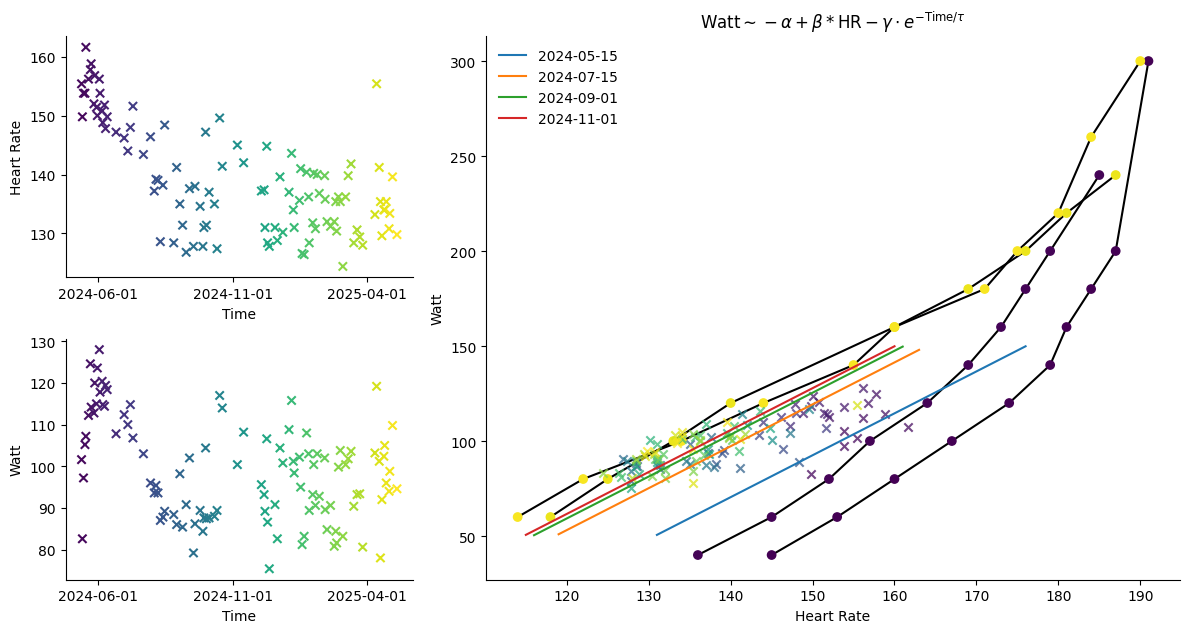

In [35]:
fig, axd = plt.subplot_mosaic(
    [["hr", "versus"], ["watt", "versus"]],
    figsize=(12, 6.44),
    gridspec_kw={"width_ratios": [1, 2]},
)

norm = plt.Normalize(
    min(sessions["Time"].min(), conconi["Time"].min()),
    max(sessions["Time"].max(), conconi["Time"].max()),
)

axd["hr"].set_ylabel("Heart Rate")
axd["hr"].scatter(
    sessions["Time"], sessions["Heart Rate"], c=sessions["Time"], norm=norm, marker="x"
)
axd["watt"].set_ylabel("Watt")
axd["watt"].scatter(
    sessions["Time"], sessions["Watt"], c=sessions["Time"], norm=norm, marker="x"
)

dates = ["2024-06-01", "2024-11-01", "2025-04-01"]
for ax in [axd["hr"], axd["watt"]]:
    ax.set_xlabel("Time")
    ax.set_xticks([compute_time(pd.to_datetime(date)) for date in dates], dates)

axd["versus"].set_title(
    r"$\text{Watt} \sim -\alpha + \beta * \text{HR} - \gamma \cdot e^{-\text{Time} / \tau}$"
)
for _, data in conconi.groupby(conconi["Timestamp"].dt.date):
    axd["versus"].plot(data["Heart Rate"], data["Watt"], color="0", zorder=-1)
    axd["versus"].scatter(data["Heart Rate"], data["Watt"], c=data["Time"], norm=norm)


for _, session in sessions.iterrows():
    axd["versus"].scatter(
        session["Heart Rate"],
        session["Watt"],
        c=session["Time"],
        norm=norm,
        marker="x",
        alpha=0.75,
    )

axd["versus"].set_xlabel("Heart Rate")
axd["versus"].set_ylabel("Watt")


hr = np.arange(110, 180, 1)

for date in pd.to_datetime(["2024-05-15", "2024-07-15", "2024-09-01", "2024-11-01"]):
    time = compute_time(date)
    power = (
        -idata.posterior["alpha"].mean().values
        + idata.posterior["beta"].mean().values * hr
        - idata.posterior["gamma"].mean().values
        * np.exp(-time / idata.posterior["tau"].mean().values)
    )
    axd["versus"].plot(
        hr[(50 < power) & (power < 150)],
        power[(50 < power) & (power < 150)],
        label=date.date(),
    )
axd["versus"].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig("rowing_hr-vs-watt.png")
plt.show()

In [ ]:
def f(x, E_0, a, b, t):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return (E_0 - a * hr) * (1 - b * np.exp(-day / t))

In [ ]:
curve_fit(f, sessions.reset_index()[["Day", "Heart Rate"]].values, sessions["Efficiency"])

In [ ]:
def f(x, E_0, b, t):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return E_0 * (1 - b * np.exp(-day / t))

In [ ]:
curve_fit(
    f,
    sessions[sessions.index > 73903].reset_index()[["Day", "Heart Rate"]].values,
    sessions[sessions.index > 73903]["Efficiency"],
)

In [ ]:
# xdata = sessions.reset_index()[["Day", "Heart Rate"]].values
# xdata[:, 1] = np.mean(xdata[:, 1])
# plt.scatter(sessions.index, sessions["Efficiency"])
# plt.plot(
#     sessions.index,
#     f(xdata, 2.03522556, 0.00444466, 0.00365812, 0.02629418),
# )
# plt.vlines([739030], 1.2, 1.6)

In [ ]:
xdata = sessions.reset_index()[["Day", "Heart Rate"]].values
xdata[:, 1] = np.mean(xdata[:, 1])
plt.scatter(sessions.index, sessions["Efficiency"])
plt.plot(
    sessions.index,
    f(xdata, 1.43562249,  0.09857152, 43.95938732),
)
plt.vlines([739030], 1.2, 1.6)

In [ ]:
def f(x, E_0, a):
    day, hr = x[:, 0] - x[:, 0].min(), x[:, 1]
    return E_0 - a * hr

In [ ]:
curve_fit(
    f,
    sessions.reset_index()[["Day", "Heart Rate"]].values,
    sessions["Efficiency"],
)

In [ ]:
xdata = sessions.reset_index()[["Day", "Heart Rate"]].values

plt.scatter(sessions.index, sessions["Efficiency"] - f(xdata, 2.13129403, 0.00516427))
# plt.plot(
#     sessions.index,
#     sessions["Efficiency"] - f(xdata, 2.13129403, 0.00516427),
# )
# plt.vlines([739030], 1.2, 1.6)

In [ ]:
sessions["Time"] = sessions.index - sessions.index.min()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.HalfNormal("alpha", sigma=50)
    beta = pm.HalfNormal("beta", sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = -alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

In [ ]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = -alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

In [ ]:
%%time
with model:
    idata2 = pm.sample(nuts_sampler="numpyro")

In [ ]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
def f(hr, a, b):
    return a + b * hr

In [ ]:
curve_fit(f, sessions["Heart Rate"], sessions["Watt"])

In [ ]:
plt.scatter(sessions["Heart Rate"], sessions["Watt"], color="0.5", s=5)

plt.title(r"$\text{Watt} \sim -\alpha + \beta * \text{HR}$")

hr = np.arange(0, 170, 1)
plt.plot(hr, -idata2.posterior["alpha"].mean().values + idata2.posterior["beta"].mean().values * hr, label=r"PyMC $\alpha \sim \mathcal{N}(0, 2)$")
plt.plot(hr, -idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * hr, label=r"PyMC $\alpha \sim \text{HalfNormal}(50)$")
plt.plot(hr, f(hr, -43.0136827 ,   1.01583838), label="Least Squares")
plt.legend(frameon=False)
plt.xlabel("Heart Rate")
plt.ylabel("Watt")
sns.despine()
plt.show()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=2, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta * sessions["Heart Rate"]

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [ ]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

In [ ]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    eta = pm.HalfNormal("eta", sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    tau = pm.Normal("tau", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    # E_0 * (1 - b * np.exp(-day / t))
    # (E_0 - a * hr) * (1 - b * np.exp(-day / t))
    mu = eta * (1 - np.exp(tau - sessions["Time"].values / beta))

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [ ]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

In [ ]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(sessions["Time"], sessions["Efficiency"])
plt.plot(
    sessions["Time"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    # (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(-sessions["Time"].values / beta))

        idata.posterior["eta"].mean().values
 
    * (
        1
        - np.exp(
            idata.posterior["tau"].mean().values
            - sessions["Time"].values / idata.posterior["beta"].mean().values
        )
    ),
)

In [ ]:
sessions["Time"] = sessions.index - sessions.index.min()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    eta = pm.HalfNormal("eta", sigma=1)
    alpha = pm.HalfNormal("alpha", sigma=1)
    beta = pm.HalfNormal("beta", sigma=1)
    tau = pm.Normal("tau", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    # E_0 * (1 - b * np.exp(-day / t))
    # (E_0 - a * hr) * (1 - b * np.exp(-day / t))
    mu = (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(tau - sessions["Time"].values / beta))

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Efficiency"])

In [ ]:
%%time
with model:
    idata = pm.sample(nuts_sampler="numpyro")

In [ ]:
az.plot_trace(idata, combined=True)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
plt.scatter(sessions["Heart Rate"], sessions["Efficiency"])
plt.plot(
    sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    idata.posterior["eta"].mean().values - idata.posterior["alpha"].mean().values * sessions["Heart Rate"]
)

In [ ]:
plt.scatter(sessions["Time"], sessions["Efficiency"])
plt.plot(
    sessions["Time"],
    # idata.posterior["alpha"].mean().values + idata.posterior["beta"].mean().values * sessions["Heart Rate"],
    # idata.posterior["alpha"].mean().values * (1 - np.exp(-sessions["Time"].values / idata.posterior["beta"].mean().values))
    # (eta - alpha * sessions["Heart Rate"]) * (1 - np.exp(-sessions["Time"].values / beta))
    (
        idata.posterior["eta"].mean().values
        - idata.posterior["alpha"].mean().values * sessions["Heart Rate"].mean()
    )
    * (
        1
        - np.exp(
            idata.posterior["tau"].mean().values
            - sessions["Time"].values / idata.posterior["beta"].mean().values
        )
    ),
)

In [ ]:
import xarray as xr

post = idata.posterior
mu_pp = post["alpha"] + post["beta"] * xr.DataArray(sessions["Heart Rate"], dims=["obs_id"])

In [ ]:
with model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

In [ ]:
_, ax = plt.subplots()

ax.plot(
    sessions["Heart Rate"], mu_pp.mean(("chain", "draw")), label="Mean outcome", color="C1"
)
ax.scatter(sessions["Heart Rate"], idata.observed_data["Y_obs"])
az.plot_hdi(sessions["Heart Rate"], idata.posterior_predictive["Y_obs"])

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Outcome (stdz)");

In [ ]:
_, ax = plt.subplots()

ax.plot(
    sessions["Time"], mu_pp.mean(("chain", "draw")), label="Mean outcome", color="C1"
)
ax.scatter(sessions["Time"], idata.observed_data["Y_obs"])
az.plot_hdi(sessions["Time"], idata.posterior_predictive["Y_obs"])

ax.set_xlabel("Predictor (stdz)")
ax.set_ylabel("Outcome (stdz)");

In [ ]:
conconi["Date"] = conconi["Timestamp"].dt.date
tests = conconi.pivot(columns=["Date"], index=["Watt"], values=["Heart Rate"])
tests["Heart Rate"][datetime.fromisoformat("2024-05-06").date()].loc[
    [watt for watt in tests.index if watt > 150]
] = pd.NA
tests["Heart Rate"][datetime.fromisoformat("2024-05-09").date()].loc[
    [watt for watt in tests.index if watt > 150]
] = pd.NA
tests["Heart Rate"][datetime.fromisoformat("2025-04-23").date()].loc[
    [watt for watt in tests.index if watt > 240]
] = pd.NA
tests["Heart Rate"][datetime.fromisoformat("2025-05-01").date()].loc[
    [watt for watt in tests.index if watt > 240]
] = pd.NA
tests

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=[320, 280, 230, 230], sigma=30, shape=len(tests.columns))
    beta = pm.Normal("beta", mu=2.5, sigma=0.2)
    sigma = pm.HalfNormal("sigma", sigma=3)

    for i, (_, test) in enumerate(tests.items()):
        test = test.dropna()

        # Expected value of outcome
        mu = -alpha[i] + beta * test.values

        # Likelihood (sampling distribution) of observations
        pm.Normal(f"Y_{i}", mu=mu, sigma=sigma, observed=test.index.values)

with model:
    conconi_trace = pm.sample(nuts_sampler="numpyro", target_accept=0.75)

az.plot_trace(conconi_trace, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
plt.suptitle("Conconi tests")
plt.tight_layout()
plt.show()

In [ ]:
for query, marker in (("Watt < 150", "o"), ("Watt > 150", "x")):
    plt.scatter(
        conconi.query(query)["Heart Rate"],
        conconi.query(query)["Watt"],
        marker=marker,
        c="0.5",
    )
hr = np.arange(110, 180, 1)
for i in range(4):
    plt.plot(
        hr,
        -conconi_trace.posterior["alpha"][:, :, i].mean().values
        + conconi_trace.posterior["beta"].mean().values * hr,
    )

plt.xlabel("Heart Rate")
plt.ylabel("Watt")

sns.despine()
plt.show()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", sigma=[275, 200], mu=50, shape=2)
    beta = pm.Normal("beta", mu=2.5, sigma=0.2)
    sigma = pm.Normal("sigma", sigma=10, mu=5, shape=2)

    for i, (_, test) in enumerate(tests.items()):
        j = i // 2
        test = test.dropna()

        # Expected value of outcome
        mu = -alpha[j] + beta * test.values

        # Likelihood (sampling distribution) of observations
        pm.Normal(f"Y_{i}", mu=mu, sigma=sigma[j], observed=test.index.values)

with model:
    conconi_trace = pm.sample(nuts_sampler="numpyro")

az.plot_trace(conconi_trace, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
plt.suptitle("Conconi tests")
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", sigma=[275, 200], mu=50, shape=2)
    beta = pm.Normal("beta", mu=2.5, sigma=0.2, shape=2)
    sigma = pm.Normal("sigma", sigma=10, mu=5, shape=2)

    for i, (_, test) in enumerate(tests.items()):
        j = i // 2
        test = test.dropna()

        # Expected value of outcome
        mu = -alpha[j] + beta[j] * test.values

        # Likelihood (sampling distribution) of observations
        pm.Normal(f"Y_{i}", mu=mu, sigma=sigma[j], observed=test.index.values)

with model:
    conconi_trace = pm.sample(nuts_sampler="numpyro")

az.plot_trace(conconi_trace, combined=True, figsize=(6, len(model.unobserved_RVs)+1))
sns.despine()
plt.suptitle("Conconi tests")
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as model:
    # Priors for unknown model parameters
    alpha = pm.Normal(
        "alpha",
        mu=200,
        sigma=conconi_trace.posterior["alpha"].std().values,
    )
    gamma = pm.Normal(
        "gamma",
        mu=75,
        sigma=conconi_trace.posterior["alpha"].std().values,
    )
    beta = pm.Normal(
        "beta",
        mu=conconi_trace.posterior["beta"].mean().values,
        sigma=conconi_trace.posterior["beta"].std().values,
    )
    sigma = pm.Normal(
        "sigma",
        mu=conconi_trace.posterior["sigma"].mean().values * 2,
        sigma=conconi_trace.posterior["sigma"].std().values * 5,
    )
    tau = pm.HalfNormal("tau", sigma=50)

    # Expected value of outcome
    mu = (
        -alpha
        + beta * sessions["Heart Rate"].values
        - gamma * np.exp(-sessions["Time"].values / tau)
    )

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=sessions["Watt"])

with model:
    idata = pm.sample(nuts_sampler="numpyro")

az.plot_trace(idata, combined=True, figsize=(6, len(model.unobserved_RVs) + 1))
sns.despine()
plt.suptitle("With prior from Conconi")
plt.tight_layout()
plt.show()

In [ ]:
conconi_trace.posterior["beta"].mean().values, conconi_trace.posterior["beta"].std().values,